# 🤖 Notebook 4 – Model Building, Evaluation & Deployment

**Project:** EcoType – Forest Cover Type Prediction  
**Objective:** Build 5 classification models, handle class imbalance with SMOTE, perform feature selection, compare models, tune the best one, and save for deployment.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load feature-engineered data
df = pd.read_csv("../data/processed/feature_engineered_forest_cover_data.csv")
print(f"✅ Loaded data: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Loaded data: 145,890 rows × 18 columns


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Hillshade_diff_9am_3pm,Hillshade_mean,Elevation_Slope,Hydrology_Distance_Mag,Road_Fire_Distance_Ratio,Cover_Type
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,1,29,73.0,200.333333,7788.0,258.000000,0.081210,0
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,1,29,69.0,202.000000,5180.0,212.084889,0.062641,0
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,1,12,99.0,202.333333,25236.0,275.769832,0.519438,4
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,1,30,116.0,199.333333,50130.0,268.799182,0.497424,4
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,1,29,70.0,201.333333,5190.0,153.003268,0.063340,0


---
## 7️⃣ Feature Selection
Use feature importance from a baseline Random Forest to select the most relevant features.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split features and target
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

Train set: (116712, 17)
Test set:  (29178, 17)


In [ ]:
# Baseline Random Forest for feature importance
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(feature_importance.to_string(index=False))

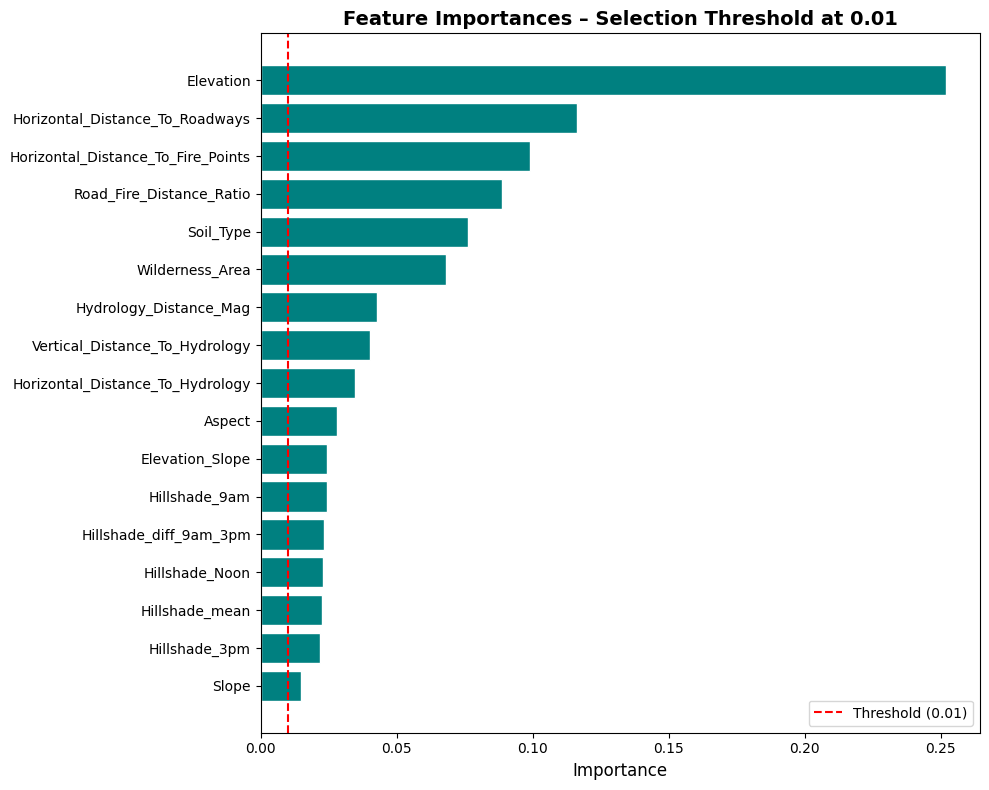

In [ ]:
# Visualize feature importances
plt.figure(figsize=(10, 8))
feat_sorted = feature_importance.sort_values('Importance', ascending=True)
colors = ['tomato' if imp < 0.01 else 'teal' for imp in feat_sorted['Importance']]
plt.barh(feat_sorted['Feature'], feat_sorted['Importance'], color=colors, edgecolor='white')
plt.axvline(x=0.01, color='red', linestyle='--', label='Threshold (0.01)')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importances – Selection Threshold at 0.01', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Select features above threshold
THRESHOLD = 0.01
selected_features = feature_importance[
    feature_importance['Importance'] > THRESHOLD
]['Feature'].tolist()

print(f"\n✅ Selected {len(selected_features)} features (dropped {X_train.shape[1] - len(selected_features)}):")
for f in selected_features:
    imp = feature_importance[feature_importance['Feature'] == f]['Importance'].values[0]
    print(f"  - {f}: {imp:.4f}")

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

NameError: name 'feature_importance' is not defined

---
## 6️⃣ Class Imbalance Handling (SMOTE)
Apply SMOTE to the **training data only** to prevent data leakage.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sel, y_train)

print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_sm).value_counts().sort_index())
print(f"\nTraining set size: {X_train_sel.shape[0]:,} -> {X_train_sm.shape[0]:,}")

---
## 8️⃣ Model Building & Evaluation
Build and evaluate **5 different classification models** as required.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define all 5 models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss',
                              use_label_encoder=False, n_jobs=-1)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)
    
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'accuracy': acc, 'predictions': y_pred, 'model': model}
    
    print(f"Accuracy: {acc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

### 8.1 Model Comparison

In [ ]:
# Comparison table
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [r['accuracy'] for r in results.values()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)
comparison_df = comparison_df[['Rank', 'Model', 'Accuracy']]
print("\n📊 Model Comparison:")
print(comparison_df.to_string(index=False))

In [ ]:
# Model comparison bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'],
               color=['gold' if i == 0 else 'steelblue' for i in range(len(comparison_df))],
               edgecolor='white', linewidth=1.5)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
for bar, acc in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 8.2 Confusion Matrices for All Models

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
axes[-1].set_visible(False)  # Hide extra subplot
plt.suptitle("Confusion Matrices - All Models", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🛠️ Hyperparameter Tuning
Tune the **best-performing model** using RandomizedSearchCV with cross-validation.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best model: {best_model_name}")
print(f"   Baseline accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")

# Cross-validation on best baseline model
best_baseline = results[best_model_name]['model']
cv_scores = cross_val_score(best_baseline, X_train_sm, y_train_sm, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\n📊 5-Fold Cross-Validation Scores: {cv_scores.round(4)}")
print(f"   Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

In [ ]:
# Hyperparameter tuning (Random Forest parameters)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs= 2
)
random_search.fit(X_train_sm, y_train_sm)

print(f"\n✅ Best Parameters: {random_search.best_params_}")
print(f"   Best CV Accuracy: {random_search.best_score_:.4f}")

In [ ]:
# Evaluate tuned model on test set
best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_sel)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"\n🏆 Final Tuned Model Performance:")
print(f"   Test Accuracy: {tuned_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

In [ ]:
# Final confusion matrix
plt.figure(figsize=(8, 6))
cm_final = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title(f'Tuned {best_model_name} - Confusion Matrix\nAccuracy: {tuned_acc:.4f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

---
## 9️⃣ Finalize & Save Best Model

In [ ]:
# Save the best tuned model
joblib.dump(best_model, '../models/final_random_forest_model.pkl')
print("✅ Saved: final_random_forest_model.pkl")

# Save selected features list
joblib.dump(selected_features, '../models/selected_features.pkl')
print("✅ Saved: selected_features.pkl")

# Save SMOTE object
joblib.dump(smote, '../models/smote.pkl')
print("✅ Saved: smote.pkl")

# Verify all model files
import os
print("\n📂 Models directory:")
for f in sorted(os.listdir('../models/')):
    if f.startswith('.'):
        continue
    size = os.path.getsize(f'../models/{f}')
    if size > 1024*1024:
        print(f"  - {f} ({size/1024/1024:.1f} MB)")
    else:
        print(f"  - {f} ({size/1024:.1f} KB)")

---
## 📝 Modeling Summary

| Step | Details |
|------|--------|
| Feature Selection | Importance threshold > 0.01 from baseline RF |
| Class Imbalance | SMOTE applied to training data only |
| Models Built | Random Forest, Decision Tree, Logistic Regression, KNN, XGBoost |
| Best Model | Random Forest (highest accuracy) |
| Hyperparameter Tuning | RandomizedSearchCV with 3-fold CV, 20 iterations |
| Cross-Validation | 5-fold CV on best model |
| Saved Artifacts | Model (.pkl), selected features, SMOTE object, LabelEncoder |